In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import brentq, minimize
from scipy.stats import gaussian_kde, norm

DATA = Path("Boeing.csv")
R_CDS, T_CDS = .50, 5.
BLUES = ["#C6DBEF", "#9ECAE1", "#6BAED6", "#4292C6", "#2171B5", "#084594"]
NAVY = "#17365D"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


$$
dV_t=\mu V_tdt+\sigma_VV_tdW_t,
\qquad
V_{t+\Delta t}=V_t+\mu V_t\Delta t+\sigma_VV_t\sqrt{\Delta t}\,\varepsilon_t,
\quad \varepsilon_t\sim N(0,1).
$$

$$
\text{Default at }T\iff V_T<K,\qquad PD(T)=\Pr(V_T<K).
$$


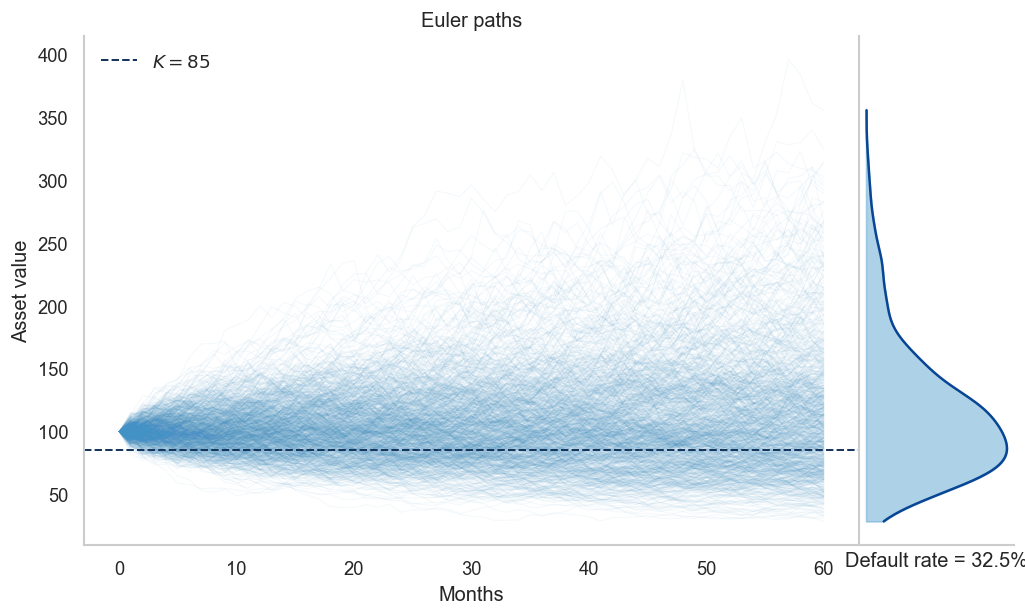

In [3]:
rng = np.random.default_rng(7)
V0, mu, sigma_v, T, dt, K, n_paths = 100, .03, .20, 5, 1/12, 85, 1_000

paths = np.empty((n_paths, int(T/dt)+1))
paths[:, 0] = V0

for t in range(1, paths.shape[1]):
    paths[:, t] = paths[:, t-1] * (
        1 + mu*dt + sigma_v*np.sqrt(dt)*rng.standard_normal(n_paths)
    )

fig, (ax, ax_d) = plt.subplots(
    1, 2, figsize=(10, 5.5), sharey=True,
    gridspec_kw={"width_ratios": [5, 1], "wspace": 0}
)

ax.plot(np.arange(paths.shape[1]), paths.T, color=BLUES[3], alpha=.06, lw=.6)
ax.axhline(K, color=NAVY, ls="--", lw=1.2, label=fr"$K={K}$")
ax.set(title="Euler paths", xlabel="Months", ylabel="Asset value")
ax.legend(frameon=False)
ax.grid(False)

terminal = paths[:, -1]
y = np.linspace(terminal.min(), terminal.max(), 400)
density = gaussian_kde(terminal)(y)

ax_d.fill_betweenx(y, 0, density, color=BLUES[2], alpha=.55)
ax_d.plot(density, y, color=BLUES[5])
ax_d.set(xticks=[], xlabel=f"Default rate = {np.mean(terminal<K):.1%}")
ax_d.grid(False)

plt.show()

$$
d_1=\frac{\ln(V/K)+(r+\tfrac12\sigma_V^2)\tau}{\sigma_V\sqrt{\tau}},
\qquad d_2=d_1-\sigma_V\sqrt{\tau}.
$$

$$
B(V,\tau)=V\Phi(-d_1)+Ke^{-r\tau}\Phi(d_2),
\qquad
s(V,\tau)=-\frac{1}{\tau}\ln\frac{B(V,\tau)}{K}-r.
$$


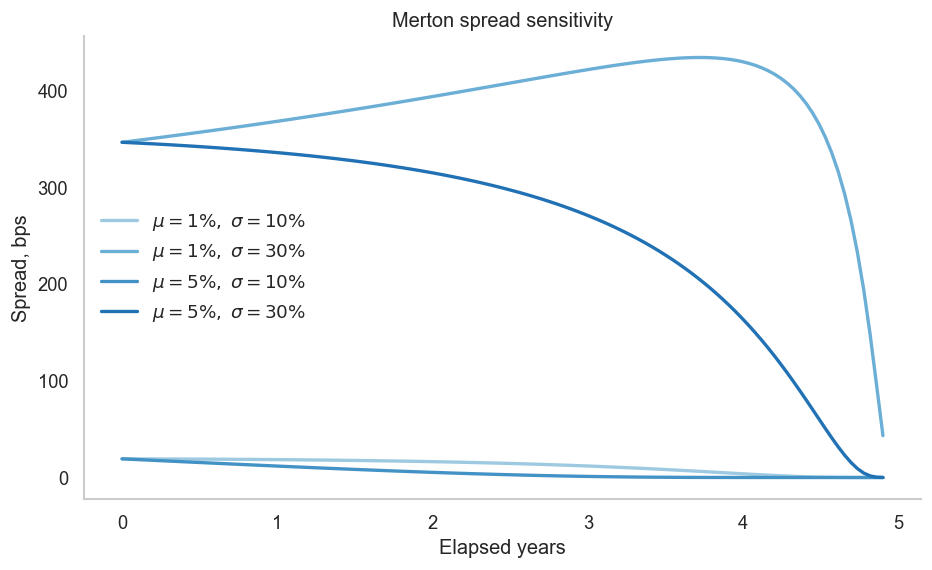

In [4]:
def merton_spread(V, K, sigma, r, tau):
    d1 = (np.log(V/K) + (r + .5*sigma**2)*tau) / (sigma*np.sqrt(tau)); d2 = d1 - sigma*np.sqrt(tau)
    debt = V*norm.cdf(-d1) + K*np.exp(-r*tau)*norm.cdf(d2)
    return (-np.log(debt/K)/tau - r) * 1e4

tau = np.linspace(5, .1, 120); elapsed = 5 - tau
specs = [(r"$\mu=1\%,\;\sigma=10\%$", .01, .10), (r"$\mu=1\%,\;\sigma=30\%$", .01, .30),
         (r"$\mu=5\%,\;\sigma=10\%$", .05, .10), (r"$\mu=5\%,\;\sigma=30\%$", .05, .30)]
fig, ax = plt.subplots(figsize=(9, 5))
for (label, drift, vol), color in zip(specs, BLUES[1:5]):
    ax.plot(elapsed, merton_spread(V0*np.exp(drift*elapsed), K, vol, .03, tau), color=color, lw=2, label=label)
ax.set(title="Merton spread sensitivity", xlabel="Elapsed years", ylabel="Spread, bps"); ax.legend(frameon=False)
ax.grid(False)
plt.show()


$$
E_t=V_t\Phi(d_{1,t})-Ke^{-rT}\Phi(d_{2,t}),
\qquad
\sigma_E=\frac{V_t}{E_t}\Phi(d_{1,t})\sigma_V.
$$

$$
DD_t=\frac{\ln(V_t/K)+(\mu_V-\tfrac12\sigma_V^2)T}{\sigma_V\sqrt{T}},
\qquad PD_t=\Phi(-DD_t).
$$


In [5]:
returns = np.array([-.33333,-.103448,-.038462,-.1112,.278128,-.176056,-.059829,.090909,-.020833,-.256596,-.029765,-.262537])
price = np.array([2.9,2.6,2.5,2.222,2.84,2.34,2.2,2.4,2.35,1.747,1.695,1.25])
shares = np.array([20778000,20778000,20808000,20808000,20808000,20808000,20808000,20808000,20856000,20856000,20856000,23056000])
equity, K, r, horizon = price*shares, .5*33_456_000, .0025, 1

def equity_value(V, sigma):
    d1 = (np.log(V/K) + (r + .5*sigma**2)*horizon) / (sigma*np.sqrt(horizon)); d2 = d1 - sigma*np.sqrt(horizon)
    return V*norm.cdf(d1) - K*np.exp(-r*horizon)*norm.cdf(d2)

sigma_asset = np.std(returns, ddof=1)*np.sqrt(12)
for _ in range(100):
    asset = np.array([brentq(lambda v: equity_value(v, sigma_asset)-e, 1, e+5*K) for e in equity])
    updated = np.std(np.diff(np.log(asset)), ddof=1)*np.sqrt(12)
    if np.isclose(updated, sigma_asset, rtol=1e-8): break
    sigma_asset = updated
mu_asset = np.mean(np.diff(np.log(asset)))*12 + .5*sigma_asset**2
dd = (np.log(asset[-1]/K) + (mu_asset-.5*sigma_asset**2)*horizon)/(sigma_asset*np.sqrt(horizon))
display(pd.DataFrame({"Asset value": asset, "Equity value": equity, "Price": price}).round(2))
display(pd.Series({"Asset volatility": sigma_asset, "Distance to default": dd, "PD": norm.cdf(-dd)}).to_frame("Value"))


,Asset value,Equity value,Price
0,76942365.64,60256200.0,2.90
1,70708860.06,54022800.0,2.60
2,68705996.90,52020000.0,2.50
3,62921015.70,46235376.0,2.22
4,75780872.95,59094720.0,2.84
5,65376553.37,48690720.0,2.34
6,62463193.92,45777600.0,2.20
7,66625105.36,49939200.0,2.40
8,65697453.31,49011600.0,2.35
9,53118614.34,36435432.0,1.75


,Value
Asset volatility,0.374794
Distance to default,1.140030
PD,0.127137


$$
D_t=\frac{\text{Debt}_t}{\text{Shares}_t},
\qquad
\sigma_{S,t}=\texttt{sigma\_stock}_t,
\qquad
c_t^{mkt}=100\cdot\texttt{spread5y}_t\;\text{bps}.
$$


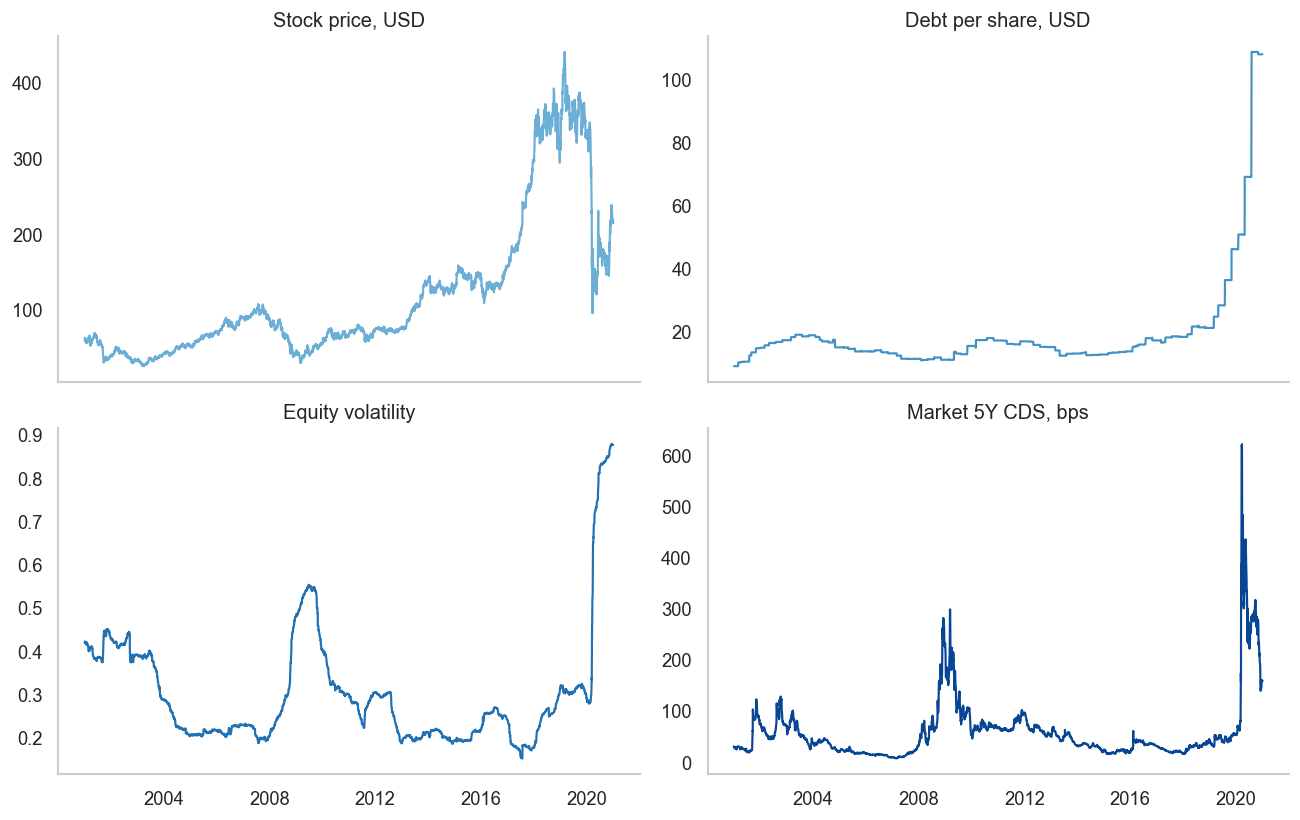

,count,mean,std,min,25%,50%,75%,max
S,5031.0,118.008,94.874,25.060,56.880,76.830,136.670,440.620
D,5031.0,18.827,15.748,8.749,12.812,15.191,17.694,108.741
sigma_stock,5031.0,0.302,0.136,0.151,0.211,0.257,0.346,0.878
market_cds_bps,5031.0,58.570,63.323,6.693,23.435,40.537,66.166,620.696
r,5031.0,0.025,0.013,0.004,0.015,0.023,0.035,0.052


In [6]:
boeing = pd.read_csv(DATA, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
boeing["market_cds_bps"] = boeing["spread5y"] * 100
series = [("S", "Stock price, USD"), ("D", "Debt per share, USD"),
          ("sigma_stock", "Equity volatility"), ("market_cds_bps", "Market 5Y CDS, bps")]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, (column, title), color in zip(axes.flat, series, BLUES[2:6]):
    ax.plot(boeing.date, boeing[column], color=color, lw=1.3); ax.set_title(title); ax.set_xlabel("")
    ax.grid(False)
plt.tight_layout(); plt.show()
display(boeing[[x[0] for x in series] + ["r"]].describe().T.round(3))


CreditGrades

$$
\sigma_{V,t}=\sigma_{S,t}\frac{S_t}{S_t+\bar LD_t},
\qquad
d_t=\frac{S_t+\bar LD_t}{\bar LD_t}e^{\lambda^2},
\qquad
A_t^2=\sigma_{V,t}^2t+\lambda^2.
$$

$$
P(t)=\Phi\!\left(-\frac{A_t}{2}+\frac{\ln d}{A_t}\right)
-d\Phi\!\left(-\frac{A_t}{2}-\frac{\ln d}{A_t}\right).
$$

$$
\xi=\frac{\lambda^2}{\sigma_V^2},
\qquad z=\sqrt{\frac14+\frac{2r}{\sigma_V^2}},
$$

$$
G(u)=d^{z+1/2}\Phi\!\left(-\frac{\ln d}{\sigma_V\sqrt u}-z\sigma_V\sqrt u\right)
+d^{-z+1/2}\Phi\!\left(-\frac{\ln d}{\sigma_V\sqrt u}+z\sigma_V\sqrt u\right),
$$

$$
c(0,T)=r(1-R)\frac{1-P(0)+e^{r\xi}[G(T+\xi)-G(\xi)]}
{P(0)-P(T)e^{-rT}-e^{r\xi}[G(T+\xi)-G(\xi)]}.
$$


In [7]:
def cg_model(data, lam=.30, Lbar=.75, R=R_CDS, T=T_CDS, sigma_mult=1):
    S, D, r = (data[x].to_numpy(float) for x in ["S", "D", "r"]); sigma_s = data["sigma_stock"].to_numpy(float)*sigma_mult
    LD = Lbar*D; sigma_v = sigma_s*S/(S+LD); d = (S+LD)/LD*np.exp(lam**2)
    A0, AT = lam, np.sqrt(sigma_v**2*T+lam**2)
    P0 = norm.cdf(-A0/2+np.log(d)/A0)-d*norm.cdf(-A0/2-np.log(d)/A0)
    PT = norm.cdf(-AT/2+np.log(d)/AT)-d*norm.cdf(-AT/2-np.log(d)/AT)
    xi, z = lam**2/sigma_v**2, np.sqrt(.25+2*r/sigma_v**2)
    def G(u):
        q, a = np.log(d)/(sigma_v*np.sqrt(u)), z*sigma_v*np.sqrt(u)
        return d**(z+.5)*norm.cdf(-q-a)+d**(-z+.5)*norm.cdf(-q+a)
    delta_g = G(T+xi)-G(xi)
    denominator = P0-PT*np.exp(-r*T)-np.exp(r*xi)*delta_g
    numerator = 1-P0+np.exp(r*xi)*delta_g
    return r*(1-R)*numerator/denominator*1e4, denominator/r

boeing["cg_baseline_bps"], boeing["rpv01_baseline"] = cg_model(boeing)

def market_annuity(data, T=T_CDS):
    a = data.r + data.market_cds_bps*1e-4/(1-R_CDS)
    return -np.expm1(-a*T)/a

boeing["market_annuity"] = market_annuity(boeing)


$$
c_t=c(S_t,D_t,r_t,\sigma_{S,t};\lambda,\bar L,R,T).
$$


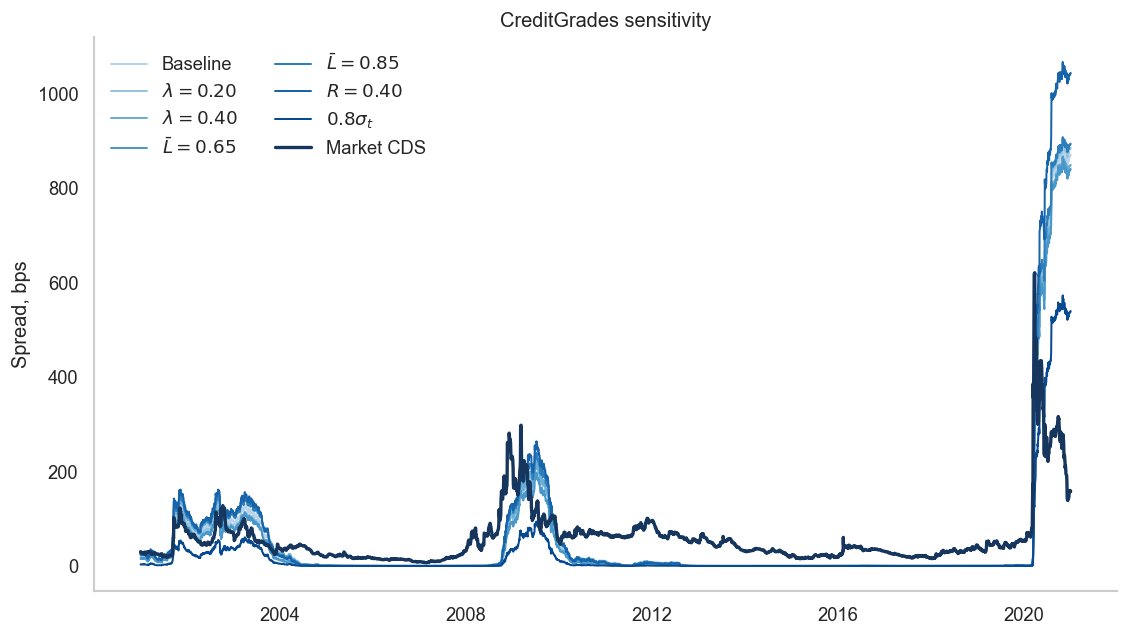

In [8]:
specifications = [
    ("Baseline", .30, .75, .50, 1.0), (r"$\lambda=0.20$", .20, .75, .50, 1.0),
    (r"$\lambda=0.40$", .40, .75, .50, 1.0), (r"$\bar L=0.65$", .30, .65, .50, 1.0),
    (r"$\bar L=0.85$", .30, .85, .50, 1.0), ("$R=0.40$", .30, .75, .40, 1.0),
    (r"$0.8\sigma_t$", .30, .75, .50, .8)]
fig, ax = plt.subplots(figsize=(11, 6))
for (label, lam, Lbar, R, mult), color in zip(specifications, plt.cm.Blues(np.linspace(.3, .9, len(specifications)))):
    ax.plot(boeing.date, cg_model(boeing, lam, Lbar, R, 5, mult)[0], color=color, lw=1.2, label=label)
ax.plot(boeing.date, boeing.market_cds_bps, color=NAVY, lw=2, label="Market CDS")
ax.set(title="CreditGrades sensitivity", xlabel="", ylabel="Spread, bps"); ax.legend(ncol=2, frameon=False)
ax.grid(False)
plt.show()


$$
\mathcal T_{train}=\{t:2001\leq\operatorname{year}(t)\leq2009\},\qquad
\mathcal T_{test}=\{t:2010\leq\operatorname{year}(t)\leq2020\}.
$$

$R=0.5$, $T=5$, $\Theta=[0.05,3]\times[0.2,1.5]$.

$$
\widehat\theta=(\widehat\lambda,\widehat{\bar L})
=\arg\min_{\theta\in\Theta}\frac{1}{|\mathcal T_{train}|}
\sum_{t\in\mathcal T_{train}}
\left[\ln c_t^{CG}(\theta)-\ln c_t^{mkt}\right]^2,
\qquad \theta^{base}=(0.3,0.75).
$$

$$
\Delta c_t^{CG}(\theta)=\alpha+\beta\Delta S_t+\varepsilon_t,
\qquad t\in\mathcal T_{train},\quad \theta\in\{\theta^{base},\widehat\theta\},
$$

$$
h_t=-A_t^{mkt}(T)\,10^{-4}\widehat\beta,
\qquad t\in\mathcal T_{test},\quad \widehat\beta<0\implies h_t>0.
$$

$\theta$ и $\widehat\beta$ фиксированы на всём тесте; $A_t^{mkt}$ меняется с рынком.


In [9]:
def hedge_regression(data, spread):
    sample = pd.DataFrame({"dc": pd.Series(spread, index=data.index).diff(), "dS": data.S.diff()}).dropna()
    fit = sm.OLS(sample.dc, sm.add_constant(sample.dS)).fit()
    return fit.params["dS"], fit.rsquared

train = boeing[boeing.date.dt.year.between(2001, 2009)].copy()
test_mask = boeing.date.dt.year.between(2010, 2020)
def objective(parameters):
    prediction = np.clip(cg_model(train, *parameters)[0], 1e-10, None)
    return np.mean((np.log(prediction)-np.log(train.market_cds_bps))**2)

fit = minimize(objective, [.30, .75], method="L-BFGS-B", bounds=[(.05, 3.0), (.20, 1.50)])
if not fit.success or not np.isfinite(fit.fun): raise RuntimeError(fit.message)
theta, records = fit.x, []
models = {"Baseline CG": "baseline", "Calibrated once": "calibrated"}
for (label, name), parameters in zip(models.items(), [(.30, .75), theta]):
    prediction = pd.Series(cg_model(boeing, *parameters)[0], index=boeing.index)
    beta, r2 = hedge_regression(train, prediction.loc[train.index])
    gap = prediction-boeing.market_cds_bps; train_gap = gap.loc[train.index]
    boeing[f"cg_{name}_bps"], boeing[f"beta_{name}"] = prediction, beta
    boeing[f"z_{name}"] = ((gap-train_gap.mean())/train_gap.std()).where(test_mask)
    records.append([*parameters, objective(parameters), beta, r2, train_gap.mean(), train_gap.std()])
estimates = pd.DataFrame(records, index=models, columns=["lambda", "Lbar", "Log-MSE train", "beta", "R2 train", "Gap mean train", "Gap SD train"])
test = boeing.loc[test_mask].copy()
display(estimates.round(4))


,lambda,Lbar,Log-MSE train,beta,R2 train,Gap mean train,Gap SD train
Baseline CG,0.3000,0.7500,19.6427,-1.016,0.1858,-10.5679,39.7107
Calibrated once,2.0471,0.3981,0.3370,-0.674,0.4940,-8.3939,39.8757


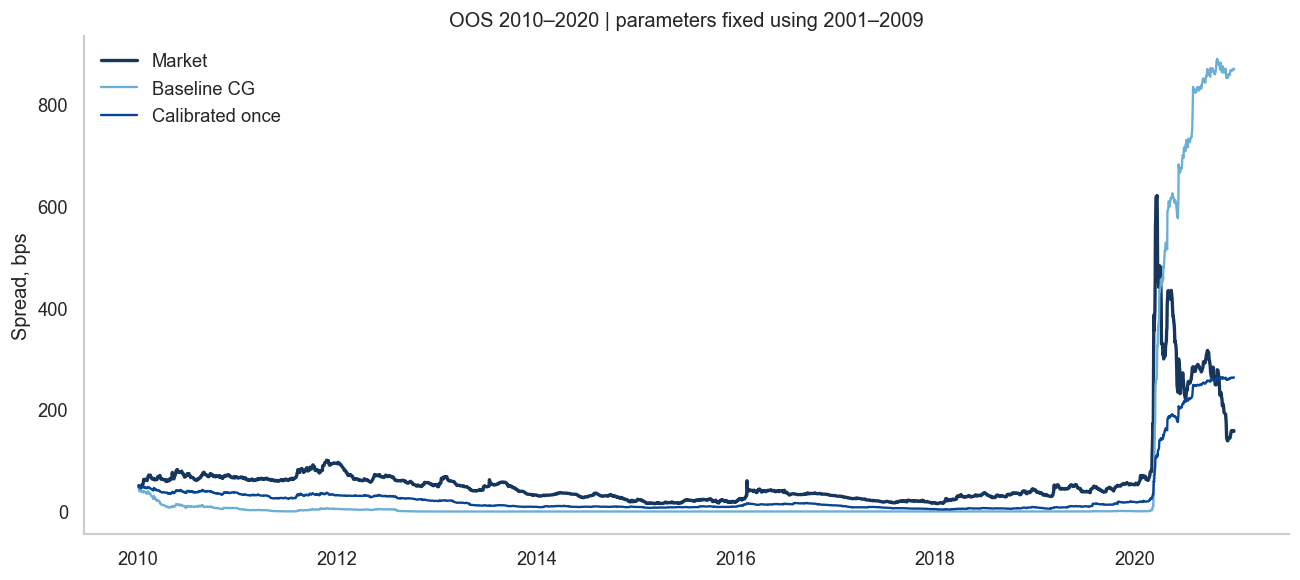

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test.date, test.market_cds_bps, color=NAVY, lw=2, label="Market")
for (label, name), color in zip(models.items(), [BLUES[2], BLUES[5]]):
    ax.plot(test.date, test[f"cg_{name}_bps"], color=color, lw=1.4, label=label)
ax.set(title="OOS 2010–2020 | parameters fixed using 2001–2009", ylabel="Spread, bps", xlabel="")
ax.legend(frameon=False)
ax.grid(False)
plt.tight_layout(); plt.show()


$$
RMSE=\sqrt{\frac1n\sum_{t=1}^n(\widehat c_t-c_t^{mkt})^2},
\qquad
MAE=\frac1n\sum_{t=1}^n|\widehat c_t-c_t^{mkt}|.
$$

$$
U_t=A_{t-1}^{mkt}(T)10^{-4}\Delta c_t^{mkt},\qquad
H_t=U_t+h_{t-1}\Delta S_t,\qquad
VR=1-\frac{\operatorname{Var}_{test}(H_t)}{\operatorname{Var}_{test}(U_t)}.
$$

$VR>0$ — хедж снижает дисперсию; $VR<0$ — увеличивает.
$U_t,H_t$ — ежедневные изменения стоимости при постоянной CDS-позиции $q=1$, без торгового сигнала и carry.


In [11]:
def model_metrics(model):
    error = model-test.market_cds_bps
    return [np.sqrt(np.mean(error**2)), np.mean(np.abs(error)), np.mean(error)]
comparison = pd.DataFrame({label: model_metrics(test[f"cg_{name}_bps"]) for label, name in models.items()},
                         index=["RMSE, bps", "MAE, bps", "Bias, bps"])
display(comparison.round(3))

unhedged = (boeing.market_annuity.shift()*boeing.market_cds_bps.diff()*1e-4).loc[test.index]
hedge_results = {}
for label, name in models.items():
    shares = -boeing.market_annuity*boeing[f"beta_{name}"]*1e-4
    hedged = unhedged+(shares.shift()*boeing.S.diff()).loc[test.index]
    hedge_results[label] = [unhedged.std()*np.sqrt(252), hedged.std()*np.sqrt(252), 1-hedged.var()/unhedged.var()]
hedge_comparison = pd.DataFrame(hedge_results, index=["Unhedged annual vol / notional", "Hedged annual vol / notional", "Variance reduction"])
display(hedge_comparison.round(4))


,Baseline CG,Calibrated once
"RMSE, bps",141.879,50.593
"MAE, bps",72.765,32.788
"Bias, bps",-7.831,-30.536


,Baseline CG,Calibrated once
Unhedged annual vol / notional,0.0394,0.0394
Hedged annual vol / notional,0.0380,0.0355
Variance reduction,0.0704,0.1861
